In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.stats as stats
import math

In [2]:
sim = Simulation("DarkSignal")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 1000
sim["SubField/NumColumns"] = 1000

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = sim["ObservingParameters/DecPointing"]

# Enable readout noise

sim["CCD/IncludeReadoutNoise"] = "yes"

In [3]:
outputWithReadoutNoise = sim.run(removeOutputFile = True)

In [4]:
sim["CCD/IncludeReadoutNoise"] = "no"
outputWithoutReadoutNoise = sim.run(removeOutputFile = True)

In [5]:
difference = outputWithReadoutNoise.getImage(0) - outputWithoutReadoutNoise.getImage(0)

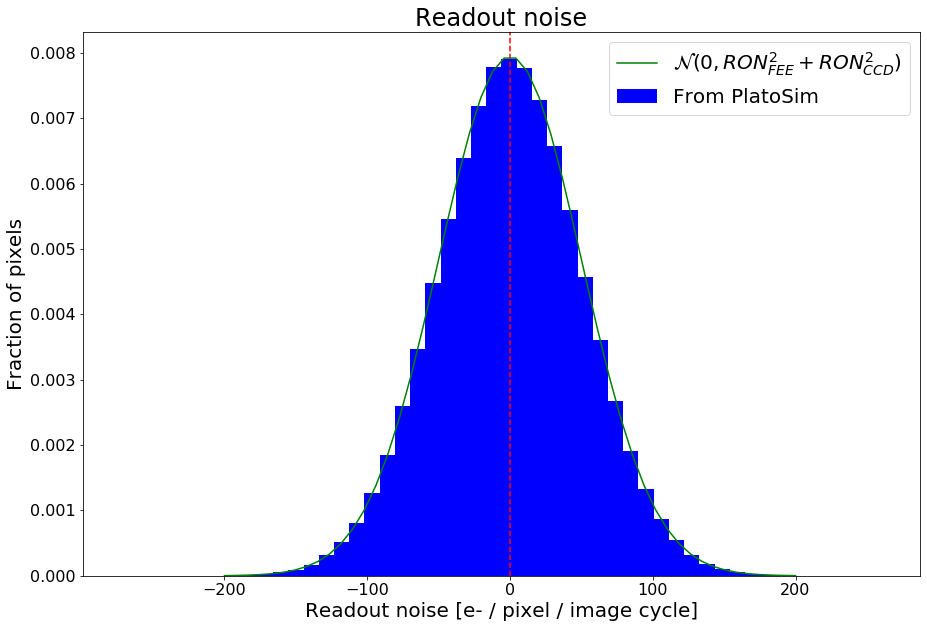

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

plt.hist(np.ravel(difference), 50, density = True, color = "b", label = "From PlatoSim")



#####################
# Normal distribution
#####################

# mu = 0
# sigma = sim["FEE/ReadoutNoise"]
# x = np.arange(-200, 200)
# label = "N(0, RON$^2$)"
# plt.plot(x, stats.norm.pdf(x, mu, sigma), "r", label = label)

plt.axvline(x = 0, color = "r", linestyle = "dashed")

mu = 0
sigma = math.sqrt(math.pow(sim["FEE/ReadoutNoise"], 2) + math.pow(sim["CCD/ReadoutNoise"], 2))
x = np.linspace(-200, 200)
plt.plot(x, scipy.stats.norm.pdf(x, mu, sigma), "g", label="$\mathcal{N} (0, RON_{FEE}^2 + RON_{CCD}^2)$")



########
# Layout
########

plt.title("Readout noise", fontsize = 24)
plt.xlabel("Readout noise [e- / pixel / image cycle]", fontsize = 20)
plt.ylabel("Fraction of pixels", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [7]:
print(np.mean(difference))
print(np.std(difference))

-0.0031020385
50.239883


In [8]:
print(math.sqrt(math.pow(sim["FEE/ReadoutNoise"], 2) + math.pow(sim["CCD/ReadoutNoise"], 2)))

50.216431573738895
